In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

## 1 chargement des données

In [15]:
# Importation des données
data = pd.read_csv("San_People_stats1.csv", sep=";")
data.head()

,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0


## 2 Description des variables 

In [16]:
# description des données
data.describe()

,height,weight,age,male
count,544.000000,544.000000,544.000000,544.000000
mean,138.263596,35.610618,29.344393,0.472426
std,27.602448,14.719178,20.746888,0.499699
min,53.975000,4.252425,0.000000,0.000000
25%,125.095000,22.007717,12.000000,0.000000
50%,148.590000,40.057844,27.000000,0.000000
75%,157.480000,47.209005,43.000000,1.000000
max,179.070000,62.992589,88.000000,1.000000


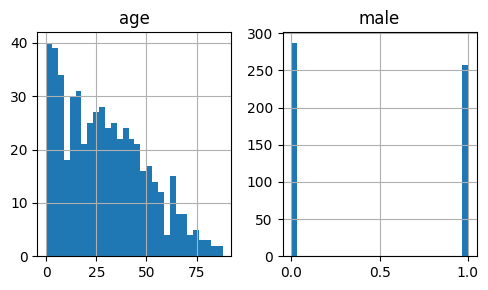

In [17]:
# Visualisation des distributions des variables
data[["age", "male"]].hist(bins=30, figsize=(5, 3))
plt.tight_layout()
plt.show()

In [18]:
count_age = data["age"].value_counts().sort_values(ascending=False)
count_age = pd.DataFrame(np.array(count_age).reshape(1, -1), columns=count_age.index)
count_age

age,1.0,3.0,5.0,12.0,41.0,43.0,29.0,6.0,8.0,35.0,...,73.9,88.0,71.0,64.5,49.5,83.4,21.5,75.5,24.2,37.4
0,22,17,16,15,15,14,12,12,12,11,...,1,1,1,1,1,1,1,1,1,1


## 3 Scatter plot du poids en fonction de la taille coloriés selon l'age

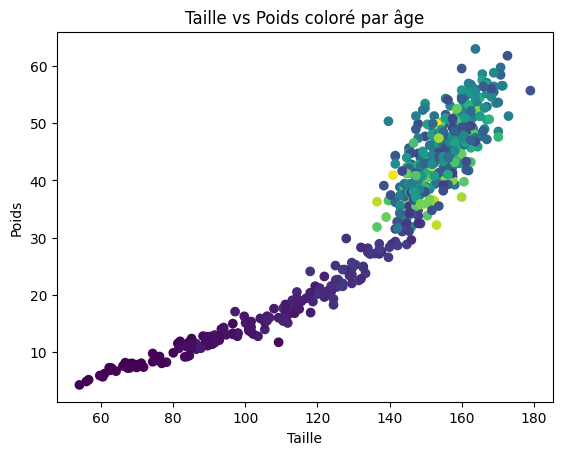

23    13.0
18    12.0
19     8.0
24     7.0
20     6.5
Name: age, dtype: float64

In [19]:
# Visualisation des données avec coloration selon la variable age
from matplotlib import colormaps
plt.scatter(data['height'], data['weight'], c=data['age'], cmap=colormaps['viridis'])
plt.xlabel('Taille')
plt.ylabel('Poids')
plt.title('Taille vs Poids coloré par âge')
plt.show()

age_fixe = data['age'][(data["height"] <= 140) & (data["weight"] <= 30)]
age_fixe.head().sort_values(ascending=False)


Le graphique montre une relation croissante entre la taille et le poids. La croissance est simultanée pour les premières tranches d’age(age <=13),puis la taille se stabilise à partir d'un certain seuil(160) tandis que le poids continue d’augmenter, avec une variabilité croissante. Les classes d’age se recouvrent partiellement. Cette visualisation reflète bien la réalité car à un certain age, l'individu
peut prendre de poids mais sa taille cesse d'augmenter.

## 4 Modèles de prédiction

##### 4.1 Modèle linéaire

In [20]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(data[['height', 'weight']], data['age'], test_size=1/3,train_size=2/3, random_state=42)

In [21]:
from sklearn.linear_model import LinearRegression
model_lin = LinearRegression()
model_lin.fit(x_train, y_train)
y_pred = model_lin.predict(x_test)

##### 4.2 Modèle K-nn

In [22]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
# on effectue une recherche du meilleur k
init_knn = KNeighborsRegressor(n_neighbors=1)
init_knn.fit(x_train, y_train)
# calcul des erreurs minimales pour k=1
mse_init_empirique = mean_squared_error(y_train, init_knn.predict(x_train))
mse_init_generalisation = mean_squared_error(y_test, init_knn.predict(x_test))
# listes pour stocker les MSE
liste_mse_generalisation = [mse_init_generalisation]
liste_mse_empirique = [mse_init_empirique]
# boucle pour k de 2 à 99
for k in range(2, 100):
    model_knn = KNeighborsRegressor(n_neighbors=k)
    model_knn.fit(x_train, y_train)
    y_pred_gen = model_knn.predict(x_test)
    y_pred_emp = model_knn.predict(x_train)
    liste_mse_generalisation.append(mean_squared_error(y_test, y_pred_gen))
    liste_mse_empirique.append(mean_squared_error(y_train, y_pred_emp))

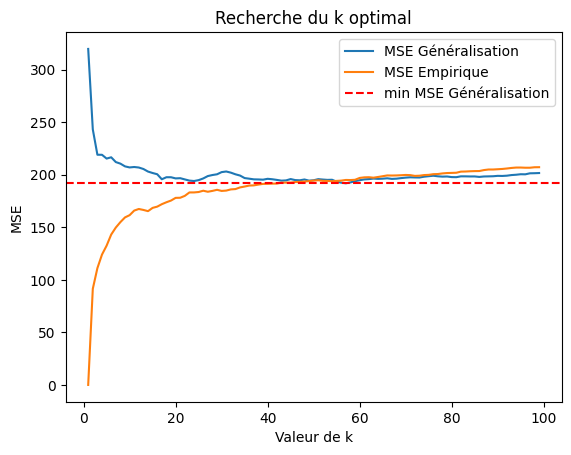

In [23]:
# Conseil : Pour visualiser votre recherche
plt.plot(range(1, 100), liste_mse_generalisation, label='MSE Généralisation')
plt.plot(range(1, 100), liste_mse_empirique, label='MSE Empirique')
plt.axhline(y=min(liste_mse_generalisation), color='r', linestyle='--', label='min MSE Généralisation')
plt.legend()
plt.xlabel('Valeur de k')
plt.ylabel('MSE')
plt.title('Recherche du k optimal')
plt.show()

L'analyse des courbes d'évolution des erreurs d'entraînement et de test permet d'identifier la zone de performance optimale du modèle.L'observation visuelle indique que le meilleur k se situe entre 1 et 20. En dehors de cet intervalle, le modèle perd soit en précision locale (trop de lissage), soit en stabilité (trop de bruit). Pour choisir le k final(best_k), nous nous basons exclusivement sur l'erreur de test. Contrairement à l'erreur d'entraînement qui est biaisée (elle tend vers zéro quand k=1), l'erreur de généralisation nous permet de mesurer la capacité du modèle à traiter des données qu'il n'a jamais rencontrées. La boucle de recherche permet d'automatiser ce choix en testant chaque valeur de k dans l'intervalle défini. Elle identifie le point où le modèle atteint le meilleur équilibre.

In [24]:
min_mse = []
for i in range(1, 20):
    model_knn = KNeighborsRegressor(n_neighbors=i)
    model_knn.fit(x_train, y_train)
    y_pred = model_knn.predict(x_test)
    min_mse.append(mean_squared_error(y_test, y_pred))
best_k = np.argmin(min_mse) + 1
print(f"Le meilleur k est {best_k} avec un MSE de {min_mse[best_k-1]}")

Le meilleur k est 17 avec un MSE de 195.6928013897867


In [25]:
# Comparaison des performances des deux modèles
mse_lin = mean_squared_error(y_test, y_pred)
print(f"MSE Régression Linéaire: {mse_lin}")
print(f"MSE KNN (k={best_k}): {min_mse[best_k-1]}")

MSE Régression Linéaire: 197.61944735320083
MSE KNN (k=17): 195.6928013897867


Nous constatons que le modèle knn présente une erreur beaucoup plus faible que le modèle linéaire. Ce résultat est logique puisque l'individu grandit sur une tranche d'age précise (la croissance n'est pas infinie). Force est de constater qu'une relation linéaire ne peut pas s'adapter à cette courbe qui casse lors du passage à l'age adulte. A l'inverse, comme le modèle knn observe le comportement des voisins locaux, il parvient à capturer efficacement ces changements de rythme de croissance.

##### meilleur modèle pour knn avec best_k comme nombre de voisins

In [26]:
model_knn_best = KNeighborsRegressor(n_neighbors=best_k)
model_knn_best.fit(x_train, y_train)
y_pred_knn_best = model_knn_best.predict(x_test)

In [27]:
score_knn = model_knn_best.score(x_test[['height', 'weight']], y_test)
score_lin = model_lin.score(x_test[['height', 'weight']], y_test)
print(f"Coefficient de détermination Régression Linéaire: {score_lin}")
print(f"Coefficient de détermination KNN (k={best_k}): {score_knn}")

Coefficient de détermination Régression Linéaire: 0.4777143867158079
Coefficient de détermination KNN (k=17): 0.5730203248000181


## 5 Modèle de prédiction avec trois variables

In [28]:
x_train, x_test, y_train, y_test = train_test_split(data[['height', 'weight', 'male']], data['age'], test_size=1/3,train_size=2/3, random_state=40)

##### 5.1 Modèle linéaire

In [29]:
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)
y_pred_linear = linear_model.predict(x_test)

err_linear = mean_squared_error(y_test, y_pred_linear)
score_linear = linear_model.score(x_test, y_test)

##### 5.2 Modèle K-nn

In [30]:
knn_model = KNeighborsRegressor(n_neighbors=best_k)
knn_model.fit(x_train, y_train)
y_pred_knn = knn_model.predict(x_test)

err_knn = mean_squared_error(y_test, y_pred_knn)
score_knn = knn_model.score(x_test, y_test)

In [31]:
print(f"Régression Linéaire avec variable 'male' : MSE = {err_linear}, coefficient de détermination = {score_linear}")
print(f"KNN avec variable 'male' (k={best_k}) : MSE = {err_knn}, coefficient de détermination = {score_knn}")

Régression Linéaire avec variable 'male' : MSE = 226.07759947457265, coefficient de détermination = 0.4682500019792949
KNN avec variable 'male' (k=17) : MSE = 189.94681451766232, coefficient de détermination = 0.5532320827956849


L'ajout de la variable binaire male entraîne une diminution des coefficients de détermination, ce qui peut sembler contre-intuitif. Cette détérioration s'explique par le fait que le modèle K-nn, basé sur la distance euclidienne, est sensible aux échelles. La variable male (binaire) est numériquement négligeable face aux amplitudes de la taille et du poids, agissant ainsi comme un bruit de fond plutôt que comme un facteur discriminant. De plus, l'augmentation de la dimensionnalité sans augmentation proportionnelle de la densité des données (particulièrement dans la zone d'hétéroscédasticité après 140 cm) rend la recherche des voisins locaux moins précise, pénalisant ainsi la robustesse globale du modèle.